# USDT/ETH (inverted ETH/USDT) Backtest

This notebook loads the price CSV, runs Al-Maghriz with the default parameter set, and plots the close price with stop-loss levels, the open-to-close equity curve (including 14 bps round-trip transaction costs), the executed position, and the drawdown.


In [1]:
import math
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / 'python'))
from al_maghriz import AlMaghrizModel

%matplotlib inline


In [2]:
csv_path = ROOT / 'examples' / 'eth_hourly.csv'
raw = pd.read_csv(csv_path, parse_dates=['timestamp'])
raw = raw.sort_values('timestamp').reset_index(drop=True)

# Invert ETH/USDT prices to USDT/ETH: open'=1/open, close'=1/close, high'=1/low, low'=1/high
df = pd.DataFrame({
    'timestamp': raw['timestamp'],
    'open': 1.0 / raw['open'],
    'close': 1.0 / raw['close'],
    'high': 1.0 / raw['low'],
    'low': 1.0 / raw['high'],
})

print(f'Loaded {len(df)} rows from {df.timestamp.min()} to {df.timestamp.max()}')
df.head()


Loaded 39653 rows from 2022-01-01 00:00:00 to 2026-07-11 04:00:00


,timestamp,open,close,high,low
0,2022-01-01 00:00:00,0.000272,0.000269,0.000272,0.000268
1,2022-01-01 01:00:00,0.000269,0.000269,0.000269,0.000267
2,2022-01-01 02:00:00,0.000269,0.000268,0.000269,0.000268
3,2022-01-01 03:00:00,0.000268,0.000269,0.000269,0.000268
4,2022-01-01 04:00:00,0.000269,0.000270,0.000270,0.000268


In [3]:
model = AlMaghrizModel(ROOT / 'dist' / 'libal_maghriz.so')
print(model.version())


Al-Maghriz Core 1.0.0


In [4]:
rolling_length = 300
max_hold_bars = 0  # 0 = auto-detect (48 for hourly, 20 for daily)
params = {"A": 2, "B": 4, "C": 0, "D": 1, "E": 0, "F": 0, "G": 2, "H": 2}

positions, stop_losses = model.predict(
    bars=df[["timestamp", "open", "high", "low", "close"]],
    token_path=ROOT / 'certificates' / 'test_20260901.pem',
    user='test',
    password='test',
    rolling_length=rolling_length,
    max_hold_bars=max_hold_bars,
    risk_per_trade=0.005,
    **params,
)

print(f'Target positions: {len(positions)}')
print(f'Stop losses: {len(stop_losses)}')
print(f'Position range: [{min(positions):.4f}, {max(positions):.4f}]')
print(f'Latest target: {positions[-1]:.6f}')
print(f'Latest stop loss: {stop_losses[-1]}')


Target positions: 39354
Stop losses: 39354
Position range: [-1.0000, 1.0000]
Latest target: 0.000000
Latest stop loss: nan


In [5]:
# --- Cost assumptions ---
# 14 bps round-trip transaction cost for crypto.
round_trip_cost_bps = 14.0

# --- Align predictions ---
# The engine returns one (position, stop_loss) per bar from index rolling_length-1 onwards.
# It executes at the open of the signal bar and holds through the close.
pred_start = rolling_length - 1
pred_idx = np.arange(pred_start, len(df))
pred_df = pd.DataFrame({
    'timestamp': df['timestamp'].iloc[pred_idx].values,
    'open': df['open'].iloc[pred_idx].values,
    'high': df['high'].iloc[pred_idx].values,
    'low': df['low'].iloc[pred_idx].values,
    'close': df['close'].iloc[pred_idx].values,
    'position': np.asarray(positions, dtype=float),
    'stop_loss': np.asarray(stop_losses, dtype=float),
})

# Open-to-close gross return for the signal bar
gross_ret = pred_df['position'] * (pred_df['close'] / pred_df['open'] - 1.0)

# Transaction cost on position change
trade_size = pred_df['position'].diff().abs()
trade_size.iloc[0] = abs(pred_df['position'].iloc[0])  # entry at first prediction bar
txn_cost = trade_size * round_trip_cost_bps / 10_000
net_ret = gross_ret - txn_cost

pred_df['gross_ret'] = gross_ret
pred_df['net_ret'] = net_ret
pred_df['equity'] = (1.0 + net_ret.fillna(0)).cumprod()
pred_df['drawdown'] = pred_df['equity'] / pred_df['equity'].cummax() - 1.0

print(f'Total return: {pred_df["equity"].iloc[-1] - 1:.2%}')
print(f'Max drawdown: {pred_df["drawdown"].min():.2%}')


Total return: 263.73%
Max drawdown: -6.27%


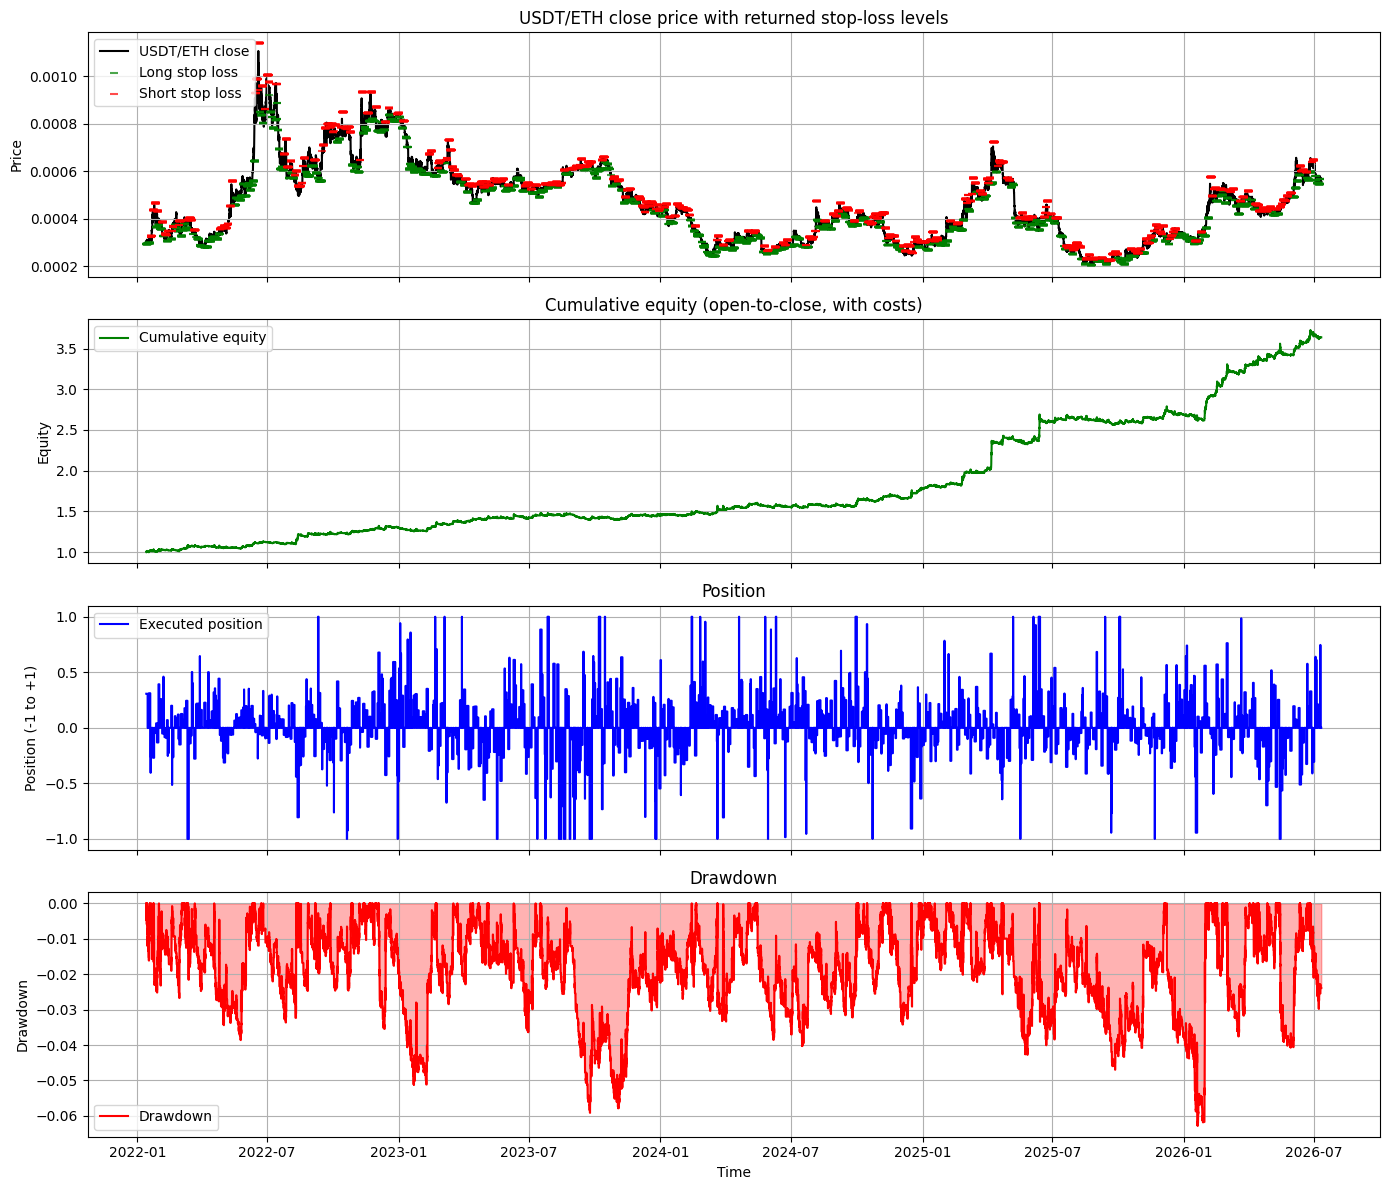

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

# Price + stop-loss levels
axes[0].plot(pred_df['timestamp'], pred_df['close'], label='USDT/ETH close', color='black', zorder=1)
long_mask = pred_df['position'] > 1e-12
short_mask = pred_df['position'] < -1e-12
sl_valid = pred_df['stop_loss'].notna() & (pred_df['stop_loss'] != 0.0) & np.isfinite(pred_df['stop_loss'])
axes[0].scatter(
    pred_df.loc[long_mask & sl_valid, 'timestamp'],
    pred_df.loc[long_mask & sl_valid, 'stop_loss'],
    marker='_', s=40, color='green', alpha=0.7, label='Long stop loss',
    zorder=2,
)
axes[0].scatter(
    pred_df.loc[short_mask & sl_valid, 'timestamp'],
    pred_df.loc[short_mask & sl_valid, 'stop_loss'],
    marker='_', s=40, color='red', alpha=0.7, label='Short stop loss',
    zorder=2,
)
axes[0].set_title('USDT/ETH close price with returned stop-loss levels')
axes[0].set_ylabel('Price')
axes[0].legend(loc='upper left')
axes[0].grid(True)

axes[1].plot(pred_df['timestamp'], pred_df['equity'], label='Cumulative equity', color='green')
axes[1].set_title('Cumulative equity (open-to-close, with costs)')
axes[1].set_ylabel('Equity')
axes[1].legend()
axes[1].grid(True)

axes[2].step(pred_df['timestamp'], pred_df['position'], where='post', label='Executed position', color='blue')
axes[2].set_title('Position')
axes[2].set_ylabel('Position (-1 to +1)')
axes[2].legend()
axes[2].grid(True)

axes[3].fill_between(pred_df['timestamp'], pred_df['drawdown'], 0, color='red', alpha=0.3)
axes[3].plot(pred_df['timestamp'], pred_df['drawdown'], color='red', label='Drawdown')
axes[3].set_title('Drawdown')
axes[3].set_ylabel('Drawdown')
axes[3].set_xlabel('Time')
axes[3].legend()
axes[3].grid(True)

plt.tight_layout()
plt.show()
